In [1]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt


Saving photo-1572478465144-f5f6573e8bfd.jpg to photo-1572478465144-f5f6573e8bfd.jpg


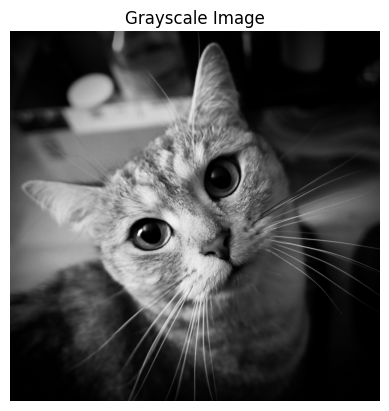

Grayscale Image Matrix:

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [2]:
# Upload grayscale image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image in grayscale
gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Display image
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

# Print matrix values
print("Grayscale Image Matrix:\n")
print(gray)


Saving original.jpg to original (3).jpg


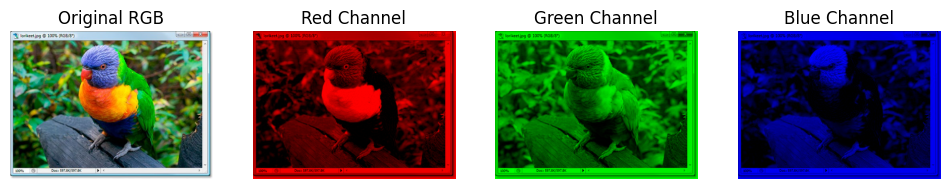

🔴 RED CHANNEL MATRIX:

[[252 131 120 ... 255 254 255]
 [248 115  68 ... 253 253 254]
 [248  65  95 ... 249 252 254]
 ...
 [255 255 251 ... 247 254 255]
 [255 255 254 ... 253 255 255]
 [255 255 254 ... 254 255 255]]

🟢 GREEN CHANNEL MATRIX:

[[255 133 117 ... 254 255 255]
 [254 119  67 ... 252 255 255]
 [255  72  96 ... 250 254 255]
 ...
 [255 254 249 ... 247 249 251]
 [255 255 254 ... 253 255 255]
 [255 255 254 ... 254 255 255]]

🔵 BLUE CHANNEL MATRIX:

[[251 128 112 ... 249 245 244]
 [254 118  65 ... 247 244 243]
 [255  80 101 ... 245 243 243]
 ...
 [253 252 250 ... 247 253 255]
 [255 255 254 ... 253 255 255]
 [255 255 254 ... 254 255 255]]


In [7]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Split channels
R, G, B = cv2.split(rgb)

# ---------- DISPLAY COLORED CHANNELS ----------
zeros = np.zeros_like(R)

red_img   = cv2.merge([R, zeros, zeros])
green_img = cv2.merge([zeros, G, zeros])
blue_img  = cv2.merge([zeros, zeros, B])

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(rgb)
plt.title("Original RGB")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(red_img)
plt.title("Red Channel")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(green_img)
plt.title("Green Channel")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(blue_img)
plt.title("Blue Channel")
plt.axis('off')

plt.show()

# ---------- PRINT MATRIX VALUES ----------
print("🔴 RED CHANNEL MATRIX:\n")
print(R)

print("\n🟢 GREEN CHANNEL MATRIX:\n")
print(G)

print("\n🔵 BLUE CHANNEL MATRIX:\n")
print(B)


Saving original.jpg to original (1).jpg


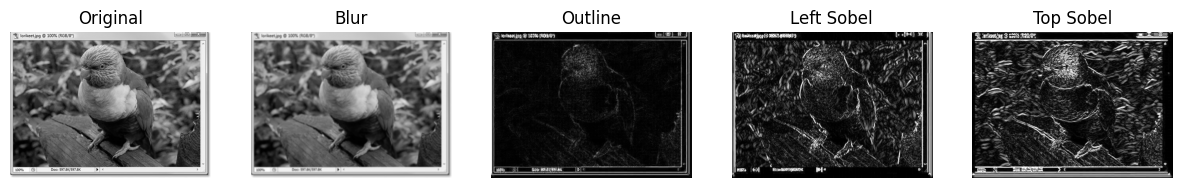

In [5]:
# Upload RGB image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read and convert to grayscale
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---- Blur Filter ----
blur = cv2.GaussianBlur(gray, (5,5), 0)

# ---- Outline Filter (Laplacian) ----
outline = cv2.Laplacian(gray, cv2.CV_64F)
outline = cv2.convertScaleAbs(outline)

# ---- Sobel Filters ----
sobel_left = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)   # X-direction (Left/Right)
sobel_top  = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)   # Y-direction (Top/Bottom)

sobel_left = cv2.convertScaleAbs(sobel_left)
sobel_top  = cv2.convertScaleAbs(sobel_top)

# ---- Display Results ----
titles = ["Original", "Blur", "Outline", "Left Sobel", "Top Sobel"]
images = [gray, blur, outline, sobel_left, sobel_top]

plt.figure(figsize=(15,6))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()
